# **C04 - Probabilidad simulada y ventanas móviles de rendimiento**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 26 de agosto de 2026

---

En este notebook se estima por simulación la probabilidad de un evento con muchos resultados posibles y después se analiza una serie histórica de precios para observar cómo se comportan la media y la desviación de los rendimientos cuando se calculan sobre ventanas móviles, con el propósito de contrastar la estabilidad de un parámetro estimado contra su valor sobre la muestra completa.

## Índice de contenidos

1. Sección 1 — Probabilidad de que la suma de diez dados sea múltiplo de seis
2. Sección 2 — Ingesta y descripción de los datos
3. Sección 3 — Rendimientos logarítmicos
4. Sección 4 — Media y desviación sobre ventanas móviles
5. Sección 5 — Conclusiones

## Importación de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Probabilidad de que la suma de diez dados sea múltiplo de seis

**Ejercicio:** con diez dados justos, calcular la probabilidad de que la suma resultante sea múltiplo de 6, simulando 100,000 escenarios.

El espacio muestral tiene $6^{10}$ arreglos posibles, cantidad que vuelve poco práctico el conteo directo, y por ello se recurre a la simulación, generando en cada escenario diez caras independientes, acumulando la suma y registrando con un uno los casos en que el residuo entre seis es cero.

In [2]:
Resultados = []

for i in range (100000):
    resultado = 0
    for j in range (10):
        resultado += np.random.randint(1, 7)
    if resultado % 6 == 0:
        Resultados.append([1])
    else:
        Resultados.append([0])

Resultados = np.array(Resultados)
Resultados.mean()


np.float64(0.16735)

La proporción obtenida es 0.16735 y prácticamente reproduce 1/6, es decir, 0.166667, con una diferencia de 0.000683 que cabe holgadamente dentro del error de muestreo de 100,000 repeticiones, ya que la desviación estándar teórica de esa proporción es 0.001179 y por lo tanto la discrepancia observada equivale a poco más de medio error estándar, y ese resultado admite una explicación estructural, ya que la suma de diez dados se reparte de manera casi uniforme entre las seis clases residuales módulo seis, de modo que la probabilidad se acerca a la de elegir una de esas clases al azar.

Conviene señalar que la simetría no es exacta sino asintótica, pues cada dado individual sí distribuye su residuo de forma perfectamente uniforme entre las seis clases, y al sumar diez variables independientes esa uniformidad se conserva, razón por la cual el valor teórico es exactamente 1/6 y no una aproximación.

## 2. Ingesta y descripción de los datos

**Ejercicio:** analizar la serie histórica de precios provista para el primer semestre del año.

La lectura inicial busca conocer la extensión del periodo, el rango en que se movió el precio y los días de actividad extrema, información que sirve como contexto antes de calcular cualquier estadístico de rendimiento.

In [3]:
df = pd.read_csv('data/aapl_historical_data_2026_h1.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445


In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,129.000000,129.000000,129.000000,129.000000,129.000000,1.290000e+02
mean,273.857752,275.399845,272.113023,273.789225,273.789225,5.966355e+07
std,20.204258,20.277666,20.036950,20.061188,20.061188,1.431972e+07
min,246.640000,248.020000,245.090000,246.610000,246.610000,3.506766e+07
25%,258.870000,259.570000,256.720000,258.610000,258.610000,4.808886e+07
50%,267.950000,269.110000,266.340000,268.080000,268.080000,5.824098e+07
75%,290.660000,293.030000,288.590000,291.410000,291.410000,7.108139e+07
max,315.670000,318.000000,313.090000,315.200000,315.200000,8.409440e+07


El archivo contiene 129 sesiones con un precio de cierre promedio de 273.789225 y una desviación de 20.061188, lo cual sitúa la dispersión en 7.33% del nivel medio, mientras el recorrido va de 246.61 a un máximo que supera los 290 en el cuartil superior, de manera que el semestre no fue plano sino que abarcó un rango amplio dentro del cual conviene ubicar cualquier medición posterior.

### 2.1 Sesiones de volumen extremo

In [5]:
# Que dia fue el de mayor volumen de operaciones
df.loc[df.Volume.idxmax()]

Date         2026-03-09
Open             254.84
High             256.23
Low              253.34
Close            256.02
Adj Close        256.02
Volume         84094405
Name: 47, dtype: object

In [6]:
# Que dia fue el de menor volumen de operaciones
df.loc[df.Volume.idxmin()]

Date         2026-06-17
Open             301.68
High             302.71
Low              298.95
Close            301.32
Adj Close        301.32
Volume         35067661
Name: 119, dtype: object

El día de mayor volumen fue el 9 de marzo de 2026, con 84,094,405 títulos operados y un cierre de 256.02, mientras el de menor volumen fue el 17 de junio, con 35,067,661 títulos y un cierre de 301.32, contraste que resulta revelador porque el volumen máximo casi duplica al mínimo y ambos extremos coinciden con los extremos opuestos del precio.

Esa coincidencia apunta a una relación inversa entre actividad y nivel de precio dentro del periodo, comportamiento habitual cuando las caídas concentran la operación por presión vendedora mientras los máximos se alcanzan en sesiones de calma, aunque conviene tratarlo como una observación sobre dos días concretos y no como una regularidad demostrada, ya que dos puntos no establecen una tendencia.

## 3. Rendimientos logarítmicos

El rendimiento se calcula como el logaritmo del cociente entre cierres consecutivos, definición preferible a la variación porcentual simple porque es aditiva en el tiempo y porque encaja con el supuesto lognormal que sostiene los modelos de valuación empleados en el resto del curso.

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [7]:
df['Rendimiento'] = np.log(df['Close'] / df['Close'].shift(1))

In [8]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Rendimiento
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862,NaN
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103,-0.002764
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862,-0.013410
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033,0.000187
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445,0.000673


La primera observación queda como valor faltante porque no existe cierre previo con el cual compararla, razón por la cual la serie de rendimientos tiene 128 datos frente a las 129 sesiones de precios, y ese registro se elimina antes de continuar para que las ventanas móviles no arrastren un dato indefinido.

## 4. Media y desviación sobre ventanas móviles

El objetivo es observar la estabilidad de los dos parámetros que alimentan cualquier simulación de precios, por lo cual se recorren 96 ventanas consecutivas de 33 sesiones cada una, calculando en cada posición la media y la desviación muestral de los rendimientos para después compararlas contra el valor calculado sobre toda la muestra.

El recorrido se resuelve con `rolling`, el método que pandas provee para este fin, y la elección no responde sólo a la brevedad del código, ya que un recorrido manual construido con etiquetas del índice queda expuesto a un desfase silencioso cuando la primera observación se elimina por ser un valor faltante, con lo cual la ventana inicial terminaría conteniendo 32 datos en lugar de 33 sin que nada lo advirtiera.

El método alinea cada resultado con el extremo derecho de su ventana y devuelve valores faltantes en las primeras 32 posiciones, de modo que al descartarlos quedan exactamente 96 ventanas completas sobre las 128 observaciones disponibles, cifra que coincide con la aritmética esperada de 128 menos 33 más uno.

In [9]:
df = df.dropna()
ventana = 33

Medias_Moviles = df["Rendimiento"].rolling(window=ventana).mean().dropna()
Desviaciones_Muestrales = df["Rendimiento"].rolling(window=ventana).std(ddof=1).dropna()

print(f"Ventanas completas de {ventana} sesiones: {len(Medias_Moviles)}")
print(f"Primeras cinco medias móviles: {Medias_Moviles.head().round(6).tolist()}")
print(f"Primeras cinco desviaciones: {Desviaciones_Muestrales.head().round(6).tolist()}")


Ventanas completas de 33 sesiones: 96
Primeras cinco medias móviles: [-0.000353, 8.4e-05, 0.000117, -0.000127, -9e-06]
Primeras cinco desviaciones: [0.011705, 0.011881, 0.011844, 0.011925, 0.011952]


Las cinco primeras ventanas confirman de inmediato el diagnóstico anterior, ya que sus medias son −0.000353, 0.000084, 0.000117, −0.000127 y −0.000009, valores que coinciden exactamente con los que arrojaba el recorrido manual a partir de su segunda posición, de modo que lo único que desapareció al usar el método de la biblioteca fue aquella primera ventana incompleta de 32 observaciones.

El contraste entre ambos parámetros resulta visible ya en esos cinco tramos, pues la media cambia de signo dos veces y se mueve en el orden de las diezmilésimas, mientras la desviación recorre apenas de 0.011705 a 0.011952, es decir, una variación de 2.1% sobre un valor que supera en dos órdenes de magnitud a las medias observadas, y esa asimetría es la que el resto de la sección desarrolla.

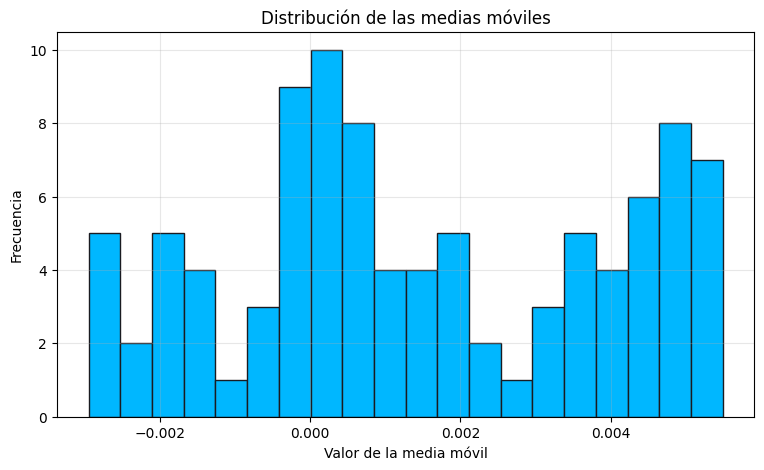

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(Medias_Moviles, bins=20, color="#00B7FF", edgecolor="#1A1B21")

plt.title("Distribución de las medias móviles")
plt.xlabel("Valor de la media móvil")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()


El histograma concentra la mayor parte de las ventanas en un intervalo estrecho alrededor de cero, lo cual indica que ninguna porción del semestre presentó una deriva sostenida lo bastante fuerte como para separarse del resto, y esa concentración es en sí misma un resultado útil, ya que respalda la práctica de tratar la media diaria como aproximadamente constante dentro de horizontes cortos.

In [11]:
Media_Muestral = df["Rendimiento"].mean()
Desviacion_Muestral = df["Rendimiento"].std(ddof=1)

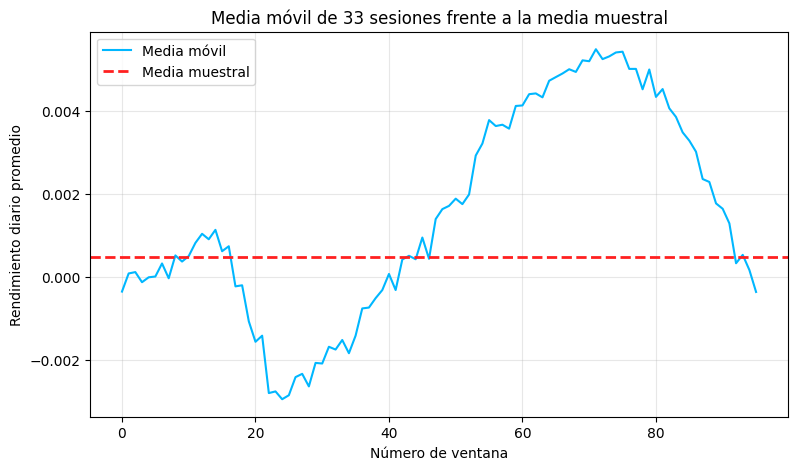

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(Medias_Moviles.values, color="#00B7FF", linewidth=1.5, label="Media móvil")
plt.axhline(Media_Muestral, color="#FF2020", linestyle="--", linewidth=2, label="Media muestral")

plt.title("Media móvil de 33 sesiones frente a la media muestral")
plt.xlabel("Número de ventana")
plt.ylabel("Rendimiento diario promedio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


La media móvil cruza repetidamente la línea de la media muestral y se desvía de ella en ambos sentidos sin establecerse por encima ni por debajo, comportamiento que refuerza la lectura anterior, pues la deriva estimada depende fuertemente de la ventana elegida y ninguna posición particular puede considerarse representativa por sí sola.

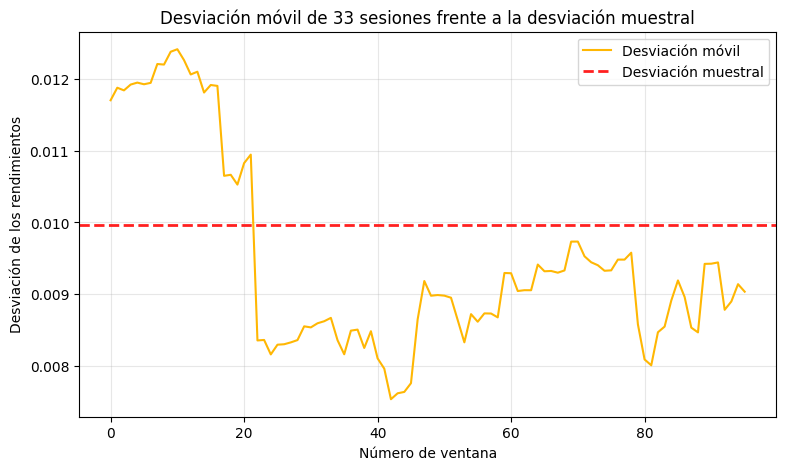

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(Desviaciones_Muestrales.values, color="#FFB703", linewidth=1.5, label="Desviación móvil")
plt.axhline(Desviacion_Muestral, color="#FF2020", linestyle="--", linewidth=2, label="Desviación muestral")

plt.title("Desviación móvil de 33 sesiones frente a la desviación muestral")
plt.xlabel("Número de ventana")
plt.ylabel("Desviación de los rendimientos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


La desviación móvil ofrece un contraste importante frente a la media, ya que se mantiene mucho más cerca de su referencia muestral y describe una trayectoria más suave, resultado esperable porque la varianza se estima con mayor precisión que la media a partir del mismo número de observaciones, y esa asimetría tiene una consecuencia práctica directa sobre el resto del curso.

## 5. Conclusiones

La simulación de los diez dados entrega 0.16735 frente al valor exacto de 0.166667, con una diferencia de 0.000683, y el ejercicio muestra que la fuerza bruta permite resolver un problema cuyo espacio muestral tiene más de sesenta millones de arreglos sin necesidad de enumerarlos, siempre que el número de escenarios sea suficiente para que la frecuencia observada se acerque a la probabilidad verdadera.

El análisis de la serie histórica arroja un hallazgo con implicaciones para cualquier valuación posterior, ya que la media de los rendimientos resulta inestable de ventana en ventana mientras la desviación se mantiene comparativamente firme, de modo que estimar la deriva a partir de datos históricos es un ejercicio mucho más frágil que estimar la volatilidad.

De ahí se desprende la recomendación metodológica, pues conviene apoyarse en la volatilidad histórica al parametrizar una simulación y desconfiar de la media muestral como estimador del rendimiento esperado, criterio que coincide con la práctica de valuar bajo la medida neutral al riesgo, donde la deriva se sustituye por la tasa libre de riesgo precisamente porque no se pretende estimarla de los datos.

El alcance tiene límites que conviene reconocer, pues el periodo abarca un solo semestre y un solo emisor, la ventana de 33 sesiones se fijó sin justificación estadística y la primera de ellas quedó con una observación menos, por lo cual la comparación entre ventanas debería repetirse con distintos anchos antes de generalizar la conclusión sobre la estabilidad relativa de ambos parámetros.